# Atividade 3.1 - Vetores

In [3]:
import numpy as np
import matplotlib.pyplot as plt

--- 
## Exercício 2-1: Reprodução da Figura 2-2

**Objetivo:** Gerar dois gráficos demonstrando:
1. A soma geométrica $\vec{v} + \vec{w}$ (regra da cauda na cabeça).
2. A diferença geométrica $\vec{v} - \vec{w}$ conectando as extremidades.

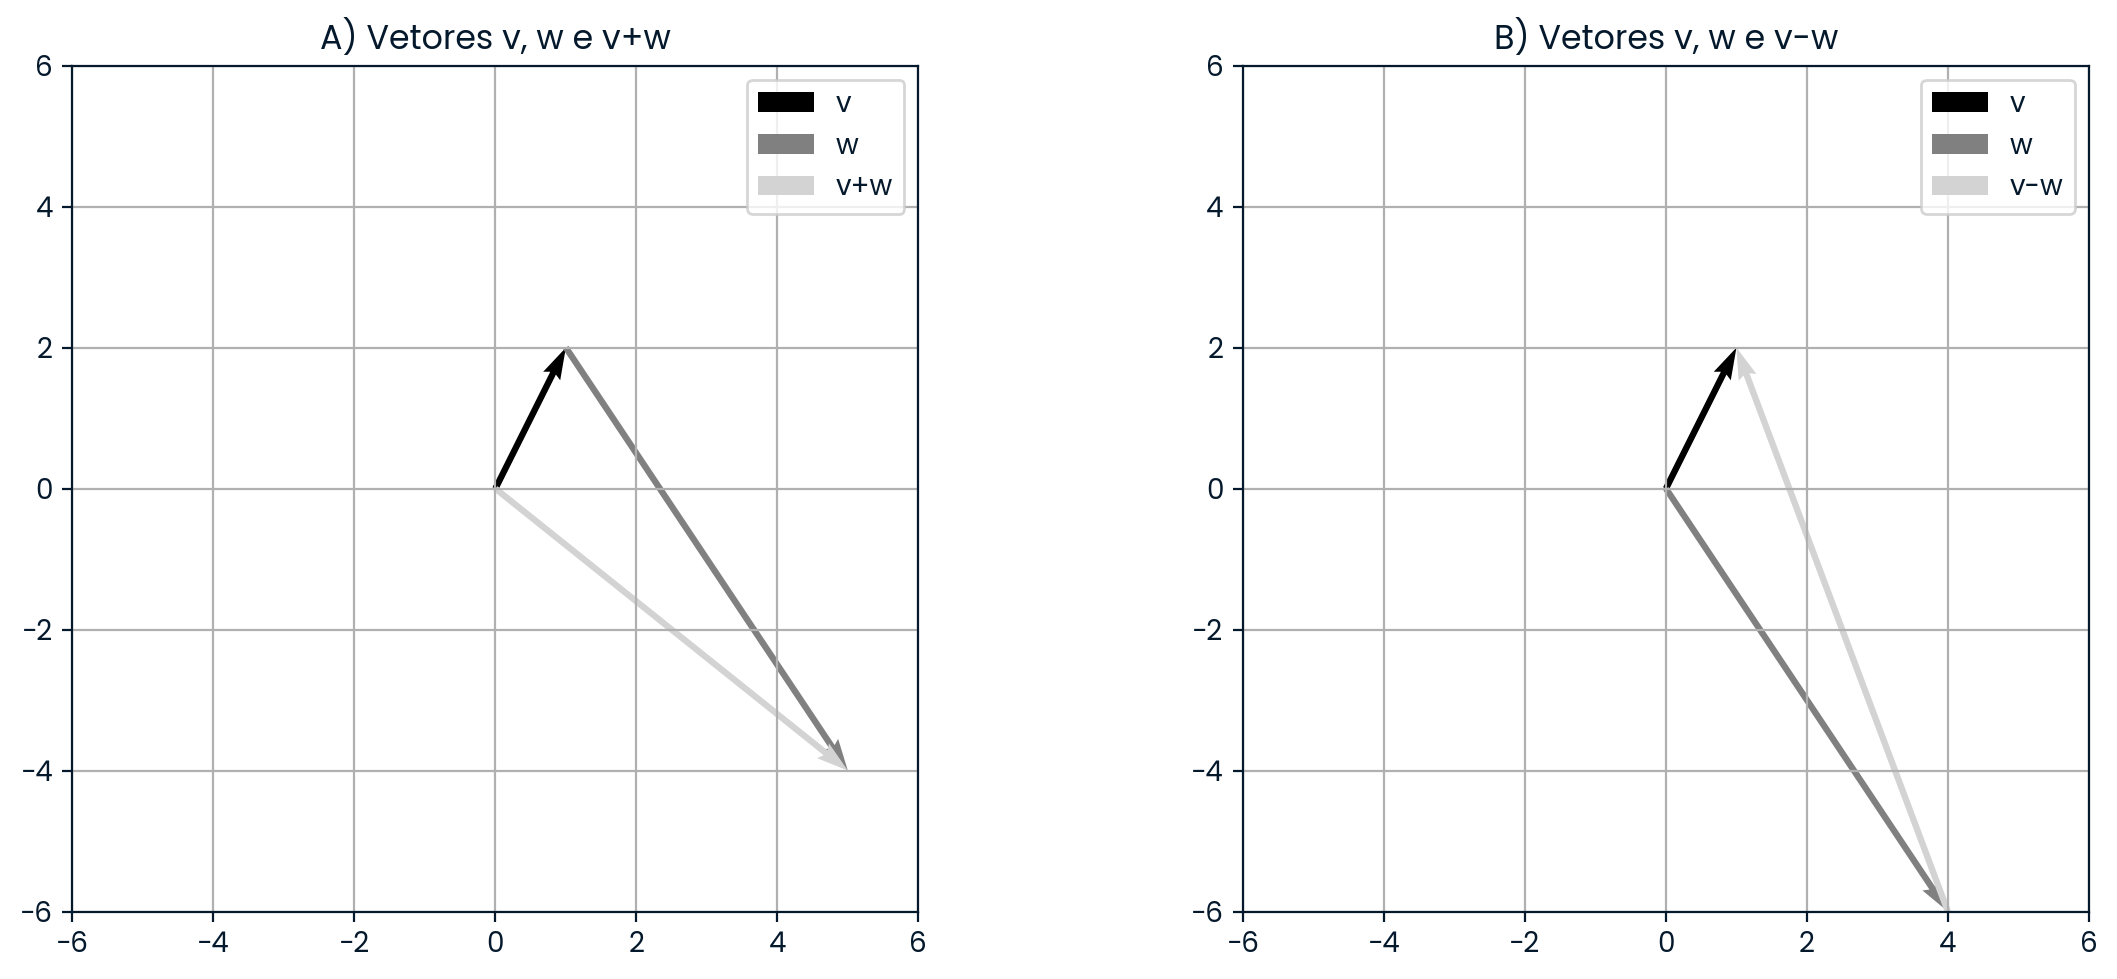

In [4]:
v = np.array([1, 2])
w = np.array([4, -6])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico A: Soma v + w
axes[0].quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1, color='black', label='v')
axes[0].quiver(v[0], v[1], w[0], w[1], angles='xy', scale_units='xy', scale=1, color='gray', label='w')
axes[0].quiver(0, 0, v[0]+w[0], v[1]+w[1], angles='xy', scale_units='xy', scale=1, color='lightgray', label='v+w')
axes[0].set_title('A) Vetores v, w e v+w')
axes[0].set_xlim([-6, 6])
axes[0].set_ylim([-6, 6])
axes[0].grid(True)
axes[0].legend()
axes[0].set_aspect('equal')

# Gráfico B: Subtração v - w
axes[1].quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1, color='black', label='v')
axes[1].quiver(0, 0, w[0], w[1], angles='xy', scale_units='xy', scale=1, color='gray', label='w')
axes[1].quiver(w[0], w[1], v[0]-w[0], v[1]-w[1], angles='xy', scale_units='xy', scale=1, color='lightgray', label='v-w')
axes[1].set_title('B) Vetores v, w e v-w')
axes[1].set_xlim([-6, 6])
axes[1].set_ylim([-6, 6])
axes[1].grid(True)
axes[1].legend()
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

--- 
## Exercício 2-2: Cálculo Manual da Norma Euclidiana

**Objetivo:** Traduzir a Equação 2-7 em código:

$$\Vert{}\vec{v}\Vert{} = \sqrt{\sum_{i=1}^{N} v_i^2}$$

E validar comparando com `np.linalg.norm()` para várias dimensões e orientações.

In [5]:
def custom_norm(vector):
    # Funciona para 1D array, vetor linha (1, N) ou vetor coluna (N, 1)
    return np.sqrt(np.sum(vector**2))

# Teste com vetor 1D aleatório de dimensão 5
v_1d = np.random.randn(5)
# Teste com vetor coluna (7, 1)
v_col = np.random.randn(7, 1)
# Teste com vetor linha (1, 4)
v_row = np.random.randn(1, 4)

print("1D - Custom:", custom_norm(v_1d), "| NumPy:", np.linalg.norm(v_1d))
print("Coluna - Custom:", custom_norm(v_col), "| NumPy:", np.linalg.norm(v_col))
print("Linha - Custom:", custom_norm(v_row), "| NumPy:", np.linalg.norm(v_row))
print("Resultados idênticos?", np.isclose(custom_norm(v_col), np.linalg.norm(v_col)))

1D - Custom: 1.8263971107789145 | NumPy: 1.8263971107789145
Coluna - Custom: 3.3783008793108 | NumPy: 3.3783008793108
Linha - Custom: 2.627819327144911 | NumPy: 2.627819327144911
Resultados idênticos? True


--- 
## Exercício 2-3: Função para Vetor Unitário e Caso do Vetor Nulo

**Objetivo:** Implementar $\hat{v} = \frac{\vec{v}}{\Vert{}\vec{v}\Vert{}}$ e analisar a divisão por zero.

In [6]:
def make_unit_vector(v):
    norm = np.linalg.norm(v)
    if norm == 0:
        raise ValueError("O vetor nulo não possui magnitude não nula e não tem direção definida; impossível normalizar!")
    return v / norm

test_v = np.array([3, 4])
u_v = make_unit_vector(test_v)
print("Vetor unitário:", u_v)
print("Norma do unitário:", np.linalg.norm(u_v))

# Testando com o vetor nulo:
try:
    make_unit_vector(np.array([0, 0, 0]))
except ValueError as e:
    print("Exceção capturada:", e)

Vetor unitário: [0.6 0.8]
Norma do unitário: 1.0
Exceção capturada: O vetor nulo não possui magnitude não nula e não tem direção definida; impossível normalizar!


--- 
## Exercício 2-4: Vetor com Magnitude Arbitrária

**Objetivo:** Retornar um vetor que preserve a direção original, mas tenha norma igual a $M$:

$$\vec{w} = M \cdot \hat{v} = M \cdot \frac{\vec{v}}{\Vert{}\vec{v}\Vert{}}$$

In [7]:
def set_vector_magnitude(v, target_magnitude):
    norm = np.linalg.norm(v)
    if norm == 0:
        raise ValueError("Não é possível redimensionar o vetor nulo para uma norma arbitrária.")
    return target_magnitude * (v / norm)

orig = np.array([1, 2, 2]) # Norma inicial: sqrt(1+4+4) = 3
resized = set_vector_magnitude(orig, 10.0)

print("Vetor redimensionado:", resized)
print("Nova norma:", np.linalg.norm(resized))

Vetor redimensionado: [3.33333333 6.66666667 6.66666667]
Nova norma: 9.999999999999998


--- 
## Exercício 2-5: Transposição Manual com Laço `for`

**Objetivo:** Transpor um vetor linha $(1, N)$ para um vetor coluna $(N, 1)$ sem usar `.T` ou `np.transpose()`.

In [8]:
row_vec = np.array([[10, 20, 30, 40]])  # shape (1, 4)
num_cols = row_vec.shape[1]

# Inicializamos um array vazio com dimensões invertidas (4, 1)
col_vec = np.zeros((num_cols, 1))

for i in range(num_cols):
    col_vec[i, 0] = row_vec[0, i]

print("Vetor linha original shape:", row_vec.shape)
print("Vetor coluna transposto shape:", col_vec.shape)
print("Conteúdo do vetor coluna:\n", col_vec)

Vetor linha original shape: (1, 4)
Vetor coluna transposto shape: (4, 1)
Conteúdo do vetor coluna:
 [[10.]
 [20.]
 [30.]
 [40.]]


--- 
## Exercício 2-6: Norma ao Quadrado e Produto Escalar Consigo Mesmo

**Objetivo:** Demonstrar numericamente a equivalência:

$$\Vert{}\vec{v}\Vert{}^2 = \vec{v} \cdot \vec{v} = \vec{v}^T \vec{v}$$

In [9]:
v = np.array([2, -3, 5, 1])

norm_squared = np.linalg.norm(v)**2
dot_self = np.dot(v, v)

print("Norma ao quadrado:", norm_squared)
print("Produto escalar v . v:", dot_self)
print("São iguais?", np.isclose(norm_squared, dot_self))

Norma ao quadrado: 39.0
Produto escalar v . v: 39
São iguais? True


--- 
## Exercício 2-7: Comutatividade do Produto Escalar

**Objetivo:** Demonstrar que $\vec{a}^T \vec{b} = \vec{b}^T \vec{a}$.

Pela definição algébrica:

$$\vec{a} \cdot \vec{b} = \sum_{i=1}^N a_i b_i = \sum_{i=1}^N b_i a_i = \vec{b} \cdot \vec{a}$$

A multiplicação de números reais é comutativa ($a_i b_i = b_i a_i$), logo o somatório preserva a comutatividade.

In [10]:
a = np.random.randn(6)
b = np.random.randn(6)

dot_ab = np.dot(a, b)
dot_ba = np.dot(b, a)

print("a . b:", dot_ab)
print("b . a:", dot_ba)
print("Diferença absoluta:", np.abs(dot_ab - dot_ba))

a . b: -1.4593147909170565
b . a: -1.4593147909170565
Diferença absoluta: 0.0


--- 
## Exercício 2-8: Visualização da Projeção Ortogonal (Figura 2-6)

**Objetivo:** Projetar $\vec{b}$ sobre a reta de $\vec{a}$, mostrando o vetor projetado $\beta \vec{a}$ e a reta de erro perpendicular $\vec{b} - \beta \vec{a}$.

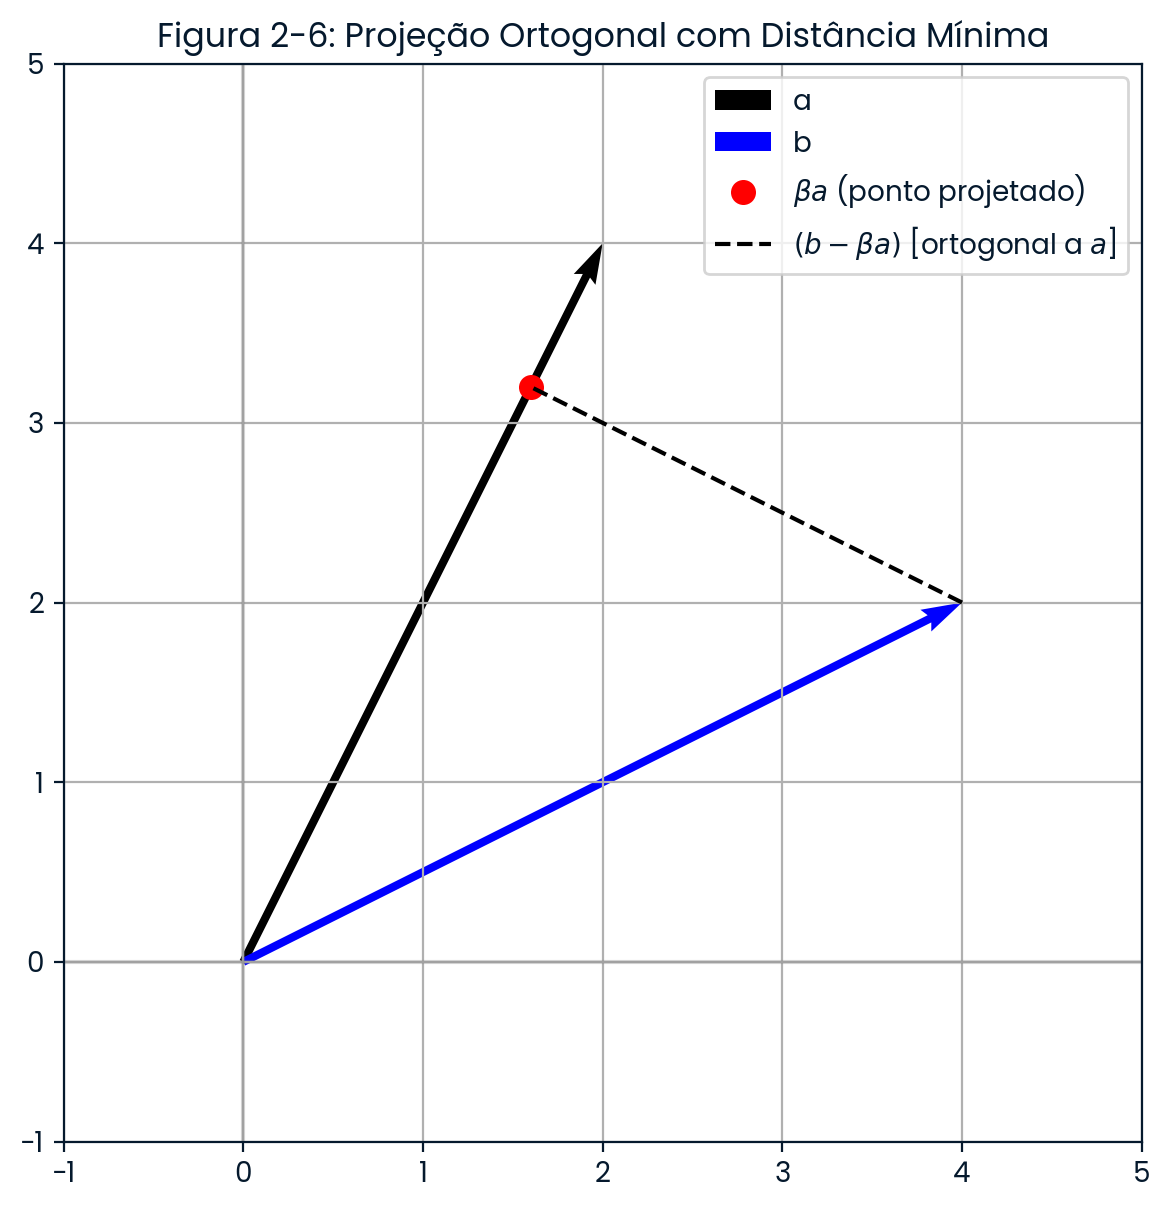

In [11]:
a = np.array([2, 4])
b = np.array([4, 2])

# Escalar de projeção beta
beta = np.dot(a, b) / np.dot(a, a)
beta_a = beta * a

plt.figure(figsize=(7, 7))
# Vetores principais
plt.quiver(0, 0, a[0], a[1], angles='xy', scale_units='xy', scale=1, color='black', label='a')
plt.quiver(0, 0, b[0], b[1], angles='xy', scale_units='xy', scale=1, color='blue', label='b')

# Ponto beta * a
plt.plot(beta_a[0], beta_a[1], 'ro', markersize=8, label=r'$\beta a$ (ponto projetado)')

# Linha de erro (b - beta*a)
plt.plot([b[0], beta_a[0]], [b[1], beta_a[1]], 'k--', label=r'$(b - \beta a)$ [ortogonal a $a$]')

plt.xlim([-1, 5])
plt.ylim([-1, 5])
plt.axhline(0, color='gray', alpha=0.3)
plt.axvline(0, color='gray', alpha=0.3)
plt.grid(True)
plt.legend()
plt.gca().set_aspect('equal')
plt.title('Figura 2-6: Projeção Ortogonal com Distância Mínima')
plt.show()

--- 
## Exercício 2-9: Decomposição Ortogonal Completa (Figura 2-8)

**Objetivo:**
1. Sortear vetores aleatórios $t$ (alvo) e $r$ (referência).
2. Calcular o componente paralelo $t_{\parallel r} = r \left( \frac{t^T r}{r^T r} \right)$ e o perpendicular $t_{\perp r} = t - t_{\parallel r}$.
3. Verificar que $t_{\parallel r} + t_{\perp r} = t$ e que $\langle t_{\parallel r}, t_{\perp r} \rangle = 0$.

Reconstrução t = t_para + t_perp confere? True
Produto escalar entre os componentes: 0.00e+00 (quase zero)


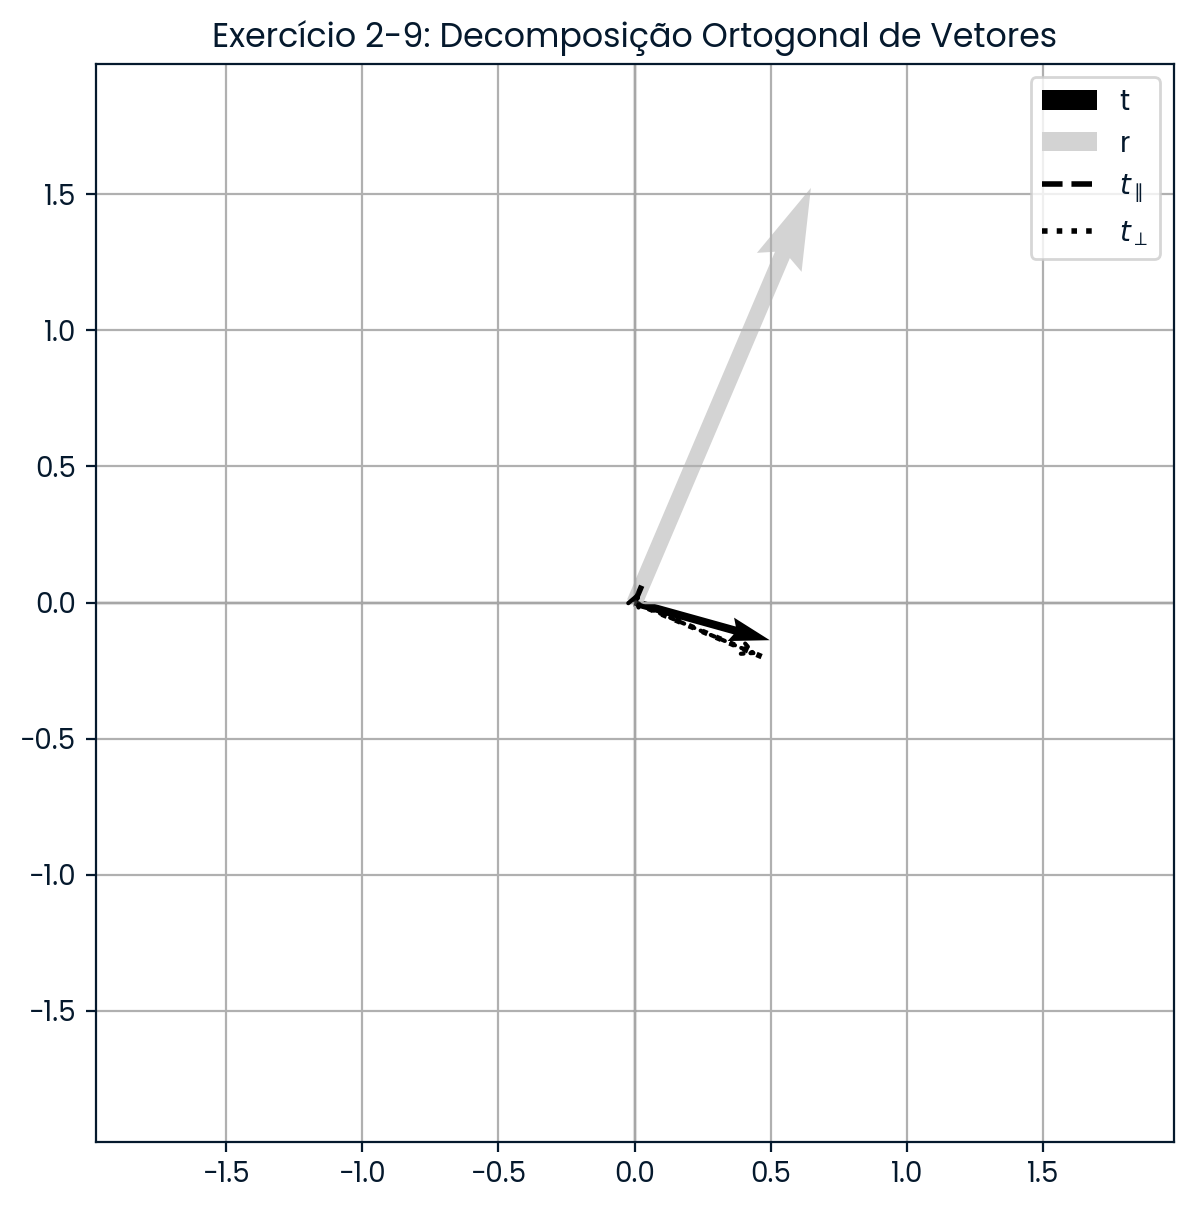

In [16]:
np.random.seed(42)
t = np.random.randn(2)
r = np.random.randn(2)

# Componentes paralelo e perpendicular
t_para = (np.dot(t, r) / np.dot(r, r)) * r
t_perp = t - t_para

# Validações algébricas
reconstrucao_ok = np.allclose(t, t_para + t_perp)
ortogonalidade = np.dot(t_para, t_perp)

print("Reconstrução t = t_para + t_perp confere?", reconstrucao_ok)
print(f"Produto escalar entre os componentes: {ortogonalidade:.2e} (quase zero)")

# Gráfico com estilos compatíveis com a legenda
plt.figure(figsize=(7, 7))

# Vetor t (preto, contínuo)
plt.quiver(0, 0, t[0], t[1], angles='xy', scale_units='xy', scale=1, 
           color='black', label='t')

# Vetor de referência r (cinzento claro, contínuo)
plt.quiver(0, 0, r[0], r[1], angles='xy', scale_units='xy', scale=1, 
           color='lightgray', width=0.015, label='r')

# Componente paralelo t_para (traçado via plot para suportar linestyle na legenda)
plt.plot([0, t_para[0]], [0, t_para[1]], 'k--', linewidth=2, label=r'$t_\parallel$')
plt.annotate('', xy=(t_para[0], t_para[1]), xytext=(0, 0),
             arrowprops=dict(arrowstyle='->', color='black', lw=1.5, ls='--'))

# Componente perpendicular t_perp (pontilhado via plot)
plt.plot([0, t_perp[0]], [0, t_perp[1]], 'k:', linewidth=2, label=r'$t_\perp$')
plt.annotate('', xy=(t_perp[0], t_perp[1]), xytext=(0, 0),
             arrowprops=dict(arrowstyle='->', color='black', lw=1.5, ls=':'))

# Limites simétricos dos eixos
max_val = max(np.max(np.abs(t)), np.max(np.abs(r))) * 1.3
plt.xlim([-max_val, max_val])
plt.ylim([-max_val, max_val])
plt.axhline(0, color='gray', alpha=0.2)
plt.axvline(0, color='gray', alpha=0.2)
plt.grid(True)
plt.legend()
plt.gca().set_aspect('equal')
plt.title('Exercício 2-9: Decomposição Ortogonal de Vetores')
plt.show()

--- 
## Exercício 2-10: Teste de Sanidade e Detecção de Bug

**Objetivo:** Implementar o erro no denominador $\frac{t^T r}{t^T t}$ e avaliar o teste de sanidade.

In [13]:
# Implementação errada (com bug no denominador: t.t em vez de r.r)
t_para_bug = (np.dot(t, r) / np.dot(t, t)) * r
t_perp_bug = t - t_para_bug

# Teste de sanidade: O componente residual continua ortogonal à referência r?
dot_correto = np.dot(t_perp, r)
dot_com_bug = np.dot(t_perp_bug, r)

print(f"Produto escalar <t_perp, r> (Correto) : {dot_correto:.4e} -> Ortogonal!")
print(f"Produto escalar <t_perp, r> (Com Bug)  : {dot_com_bug:.4f} -> FALHOU na ortogonalidade!")
print("Conclusão: O teste de sanidade revela imediatamente o bug checando se dot(t - t_para, r) == 0.")

Produto escalar <t_perp, r> (Correto) : -5.5511e-17 -> Ortogonal!
Produto escalar <t_perp, r> (Com Bug)  : -1.0340 -> FALHOU na ortogonalidade!
Conclusão: O teste de sanidade revela imediatamente o bug checando se dot(t - t_para, r) == 0.


--- 
## Exercício 3-1: Combinação Linear Ponderada com Laço `for`

**Objetivo:** Realizar a combinação linear com listas e laço `for`:

$$\vec{w} = \lambda_1 \vec{v}_1 + \lambda_2 \vec{v}_2 + \dots + \lambda_n \vec{v}_n$$

In [14]:
scalars = [1, 2, -3]
vectors = [
    np.array([4, 5, 1]),
    np.array([-4, 0, -4]),
    np.array([1, 3, 2])
]

# Inicializa com zeros com a dimensionalidade do primeiro vetor
w = np.zeros(len(vectors[0]))

for s, v in zip(scalars, vectors):
    w += s * v

print("Resultado do laço for:", w)
print("Resultado esperado   : [-7. -4. -13.]")

Resultado do laço for: [ -7.  -4. -13.]
Resultado esperado   : [-7. -4. -13.]


--- 
## Exercício 3-2: Incompatibilidade de Dimensões e Contagem de Elementos

**Objetivo:** Explorar os dois cenários de erro propostos no exercício:
1. Vetor com dimensão incompatível (um vetor em $\mathbb{R}^4$ enquanto os outros estão em $\mathbb{R}^3$).
2. Quantidade de escalares diferente da quantidade de vetores.

In [15]:
# Cenário 1: Dimensionalidades incompatíveis
print("--- Teste 1: Adicionando vetor em R^4 a um conjunto em R^3 ---")
vectors_mismatch = [
    np.array([1, 2, 3]),
    np.array([4, 5, 6, 7])  # R^4
]
scalars_test = [1, 1]

try:
    res = np.zeros(len(vectors_mismatch[0]))
    for s, v in zip(scalars_test, vectors_mismatch):
        res += s * v
except ValueError as err:
    print("Erro disparado:", err)
    print("Motivo: Vetores em R^3 e R^4 não compartilham o mesmo espaço vetorial e não podem ser somados.\n")

# Cenário 2: Quantidades diferentes de escalares e vetores
print("--- Teste 2: Mais escalares do que vetores ---")
extra_scalars = [1, 2, 3, 4]
two_vectors = [np.array([1, 2]), np.array([3, 4])]

if len(extra_scalars) != len(two_vectors):
    print(f"Alerta de dimensão: Há {len(extra_scalars)} escalares para {len(two_vectors)} vetores.")
    print("Se usar 'zip()', os escalares sobressalentes serão ignorados silenciosamente.")
    print("Se usar índices manuais `for i in range(len(extra_scalars))`, gerará IndexError ao acessar o vetor inexistente!")

--- Teste 1: Adicionando vetor em R^4 a um conjunto em R^3 ---
Erro disparado: operands could not be broadcast together with shapes (3,) (4,) (3,) 
Motivo: Vetores em R^3 e R^4 não compartilham o mesmo espaço vetorial e não podem ser somados.

--- Teste 2: Mais escalares do que vetores ---
Alerta de dimensão: Há 4 escalares para 2 vetores.
Se usar 'zip()', os escalares sobressalentes serão ignorados silenciosamente.
Se usar índices manuais `for i in range(len(extra_scalars))`, gerará IndexError ao acessar o vetor inexistente!
